# 02 - Modelado: SARIMA / SARIMAX / ETS / Prophet

**Objetivo:** comparar 5 configuraciones de modelo prediciendo demanda mensual peninsular y agregando a anual.

**Esquema:**
- Hold-out final: **2024-2025** (24 meses, intocable hasta el final)
- CV walk-forward sobre 2015-2023 (4 folds, ventana expansiva, horizonte 12 meses)
  - Fold 2020 = train 2015-01→2019-12 → predice 2020 *(COVID, reportado aparte)*
  - Fold 2021 = train 2015-01→2020-12 → predice 2021
  - Fold 2022 = train 2015-01→2021-12 → predice 2022
  - Fold 2023 = train 2015-01→2022-12 → predice 2023

**Modelos:**
| | univariante | + HDD18/CDD22 |
|---|:---:|:---:|
| SARIMA | ✓ | ✓ (=SARIMAX) |
| ETS | ✓ | — |
| Prophet | ✓ | ✓ |

**Métricas:** MAPE, RMSE y MAE mensuales + error de la suma anual (lo que se entrega).

**Nota:** se usa la temperatura *observada* en los periodos de test (evaluación ex-post). Para predicción real más allá de los datos, harían falta pronósticos de temperatura.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))

from cv       import folds_walk_forward, metricas
from modelos  import (
    predecir_sarima, predecir_ets, predecir_prophet,
    buscar_orden_sarima, buscar_config_ets,
)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100

df = (
    pd.read_csv(ROOT / 'data' / 'processed' / 'dataset_mensual.csv', parse_dates=['fecha'])
      .set_index('fecha').asfreq('MS')
)
print('Shape:', df.shape, ' Periodo:', df.index.min().date(), '->', df.index.max().date())
df.tail(3)

Shape: (132, 4)  Periodo: 2015-01-01 -> 2025-12-01


,demanda_MWh,temp_media_C,HDD18,CDD22
fecha,,,,
2025-10-01,2.045981e+07,18.653,17.255,0.0
2025-11-01,2.109896e+07,11.822,185.353,0.0
2025-12-01,2.269745e+07,9.199,272.836,0.0


## 1. Definición de splits

In [2]:
TARGET   = 'demanda_MWh'
EXOG_COLS = ['HDD18', 'CDD22']

HOLDOUT_START = '2024-01-01'
TRAIN_PRE_HOLDOUT = df.loc[:'2023-12-31']
HOLDOUT           = df.loc[HOLDOUT_START:]

FOLD_STARTS = ['2020-01-01', '2021-01-01', '2022-01-01', '2023-01-01']

print(f'Train pre-holdout : {TRAIN_PRE_HOLDOUT.index.min().date()} -> {TRAIN_PRE_HOLDOUT.index.max().date()}  ({len(TRAIN_PRE_HOLDOUT)} meses)')
print(f'Hold-out          : {HOLDOUT.index.min().date()} -> {HOLDOUT.index.max().date()}  ({len(HOLDOUT)} meses)')
print(f'Folds CV          : {FOLD_STARTS}')

Train pre-holdout : 2015-01-01 -> 2023-12-01  (108 meses)
Hold-out          : 2024-01-01 -> 2025-12-01  (24 meses)
Folds CV          : ['2020-01-01', '2021-01-01', '2022-01-01', '2023-01-01']


## 2. Selección de hiperparámetros (AIC sobre train pre-holdout)

Se busca **una sola vez** sobre 2015-2023 para evitar fuga de información de los folds individuales. La configuración elegida se reutiliza en todos los folds y en el hold-out.

In [3]:
y_full = TRAIN_PRE_HOLDOUT[TARGET]
X_full = TRAIN_PRE_HOLDOUT[EXOG_COLS]

print('Buscando orden SARIMA univariante (grid p,q in 0-2; P,Q in 0-1; d=1, D=1, m=12)...')
ord_sarima, sord_sarima, aic_sarima = buscar_orden_sarima(y_full)
print(f'  -> SARIMA{ord_sarima} x {sord_sarima}   AIC={aic_sarima:.1f}')

print('Buscando orden SARIMAX (con HDD18+CDD22)...')
ord_sarimax, sord_sarimax, aic_sarimax = buscar_orden_sarima(y_full, exog_train=X_full)
print(f'  -> SARIMAX{ord_sarimax} x {sord_sarimax}  AIC={aic_sarimax:.1f}')

print('Buscando configuracion ETS...')
cfg_ets, aic_ets = buscar_config_ets(y_full)
print(f'  -> ETS {cfg_ets}   AIC={aic_ets:.1f}')

Buscando orden SARIMA univariante (grid p,q in 0-2; P,Q in 0-1; d=1, D=1, m=12)...


  -> SARIMA(0, 1, 2) x (1, 1, 1, 12)   AIC=2403.5
Buscando orden SARIMAX (con HDD18+CDD22)...


  -> SARIMAX(0, 1, 2) x (1, 1, 1, 12)  AIC=2345.9
Buscando configuracion ETS...


  -> ETS {'trend': None, 'seasonal': 'add', 'damped_trend': False}   AIC=2890.8


## 3. Cross-validation walk-forward

Para cada fold y cada modelo: ajusta sobre `train`, predice los 12 meses del `test`, calcula métricas.

In [4]:
MODELOS = ['SARIMA', 'SARIMAX', 'ETS', 'Prophet', 'Prophet+exog']


def predecir_uno(modelo: str, train: pd.DataFrame, test: pd.DataFrame) -> pd.Series:
    y_tr = train[TARGET]
    X_tr, X_te = train[EXOG_COLS], test[EXOG_COLS]
    idx_te = test.index
    if modelo == 'SARIMA':
        return predecir_sarima(y_tr, idx_te, ord_sarima, sord_sarima)
    if modelo == 'SARIMAX':
        return predecir_sarima(y_tr, idx_te, ord_sarimax, sord_sarimax, X_tr, X_te)
    if modelo == 'ETS':
        return predecir_ets(y_tr, idx_te, **cfg_ets)
    if modelo == 'Prophet':
        return predecir_prophet(y_tr, idx_te)
    if modelo == 'Prophet+exog':
        return predecir_prophet(y_tr, idx_te, X_tr, X_te)
    raise ValueError(modelo)


filas, predicciones_cv = [], {}
for train, test, etiqueta in folds_walk_forward(TRAIN_PRE_HOLDOUT, FOLD_STARTS, horizon=12):
    print(f'Fold {etiqueta} (train n={len(train)}, test n={len(test)})')
    predicciones_cv[etiqueta] = pd.DataFrame(index=test.index)
    predicciones_cv[etiqueta]['real'] = test[TARGET]
    for modelo in MODELOS:
        pred = predecir_uno(modelo, train, test)
        predicciones_cv[etiqueta][modelo] = pred
        m = metricas(test[TARGET], pred)
        m.update({'fold': etiqueta, 'modelo': modelo})
        filas.append(m)

resultados_cv = pd.DataFrame(filas)[['fold', 'modelo', 'MAPE_%', 'RMSE_MWh', 'MAE_MWh',
                                     'anual_real_TWh', 'anual_pred_TWh', 'error_anual_%']]
print('\nDONE.')

Fold 2020 (train n=60, test n=12)


Importing plotly failed. Interactive plots will not work.


19:08:26 - cmdstanpy - INFO - Chain [1] start processing


19:08:26 - cmdstanpy - INFO - Chain [1] done processing


19:08:26 - cmdstanpy - INFO - Chain [1] start processing


...

19:08:30 - cmdstanpy - INFO - Chain [1] start processing


19:08:31 - cmdstanpy - INFO - Chain [1] done processing


19:08:31 - cmdstanpy - INFO - Chain [1] start processing


19:08:31 - cmdstanpy - INFO - Chain [1] done processing



DONE.


In [5]:
# Tabla detallada por fold y modelo
resultados_cv.round(2)

,fold,modelo,MAPE_%,RMSE_MWh,MAE_MWh,anual_real_TWh,anual_pred_TWh,error_anual_%
0,2020,SARIMA,4.97,1171780.85,1016844.36,250.05,244.82,-2.09
1,2020,SARIMAX,5.34,1326912.82,1031687.61,250.05,261.09,4.42
2,2020,ETS,6.61,1651479.29,1276122.06,250.05,265.36,6.12
3,2020,Prophet,6.03,1553832.89,1159001.38,250.05,261.18,4.45
4,2020,Prophet+exog,5.96,1563689.19,1144782.64,250.05,263.04,5.20
5,2021,SARIMA,4.03,1020467.04,844777.79,256.55,256.99,0.17
6,2021,SARIMAX,3.49,996361.78,725069.33,256.55,252.81,-1.46
7,2021,ETS,1.69,475253.61,358249.57,256.55,258.46,0.75
8,2021,Prophet,4.09,947396.25,879094.97,256.55,246.27,-4.00
9,2021,Prophet+exog,5.37,1175272.10,1146581.07,256.55,242.79,-5.36


In [6]:
# Resumen por modelo (excluyendo fold 2020 = COVID)
resumen = (
    resultados_cv[resultados_cv['fold'] != '2020']
    .groupby('modelo')
    .agg(MAPE_medio=('MAPE_%', 'mean'),
         RMSE_medio=('RMSE_MWh', 'mean'),
         err_anual_abs_medio=('error_anual_%', lambda x: np.abs(x).mean()))
    .sort_values('MAPE_medio')
)
print('Resumen CV (folds 2021-2023, sin COVID):')
print(resumen.round(2).to_string())

covid = resultados_cv[resultados_cv['fold'] == '2020'].set_index('modelo')[['MAPE_%', 'error_anual_%']]
print('\nFold 2020 (COVID) reportado aparte:')
print(covid.round(2).to_string())

Resumen CV (folds 2021-2023, sin COVID):
              MAPE_medio  RMSE_medio  err_anual_abs_medio
modelo                                                   
Prophet             2.88   713959.99                 1.87
ETS                 2.90   728759.70                 2.35
Prophet+exog        3.51   808754.96                 3.29
SARIMAX             4.38  1045738.83                 3.69
SARIMA              4.46  1111176.47                 2.94

Fold 2020 (COVID) reportado aparte:
              MAPE_%  error_anual_%
modelo                             
SARIMA          4.97          -2.09
SARIMAX         5.34           4.42
ETS             6.61           6.12
Prophet         6.03           4.45
Prophet+exog    5.96           5.20


## 4. Visualización CV

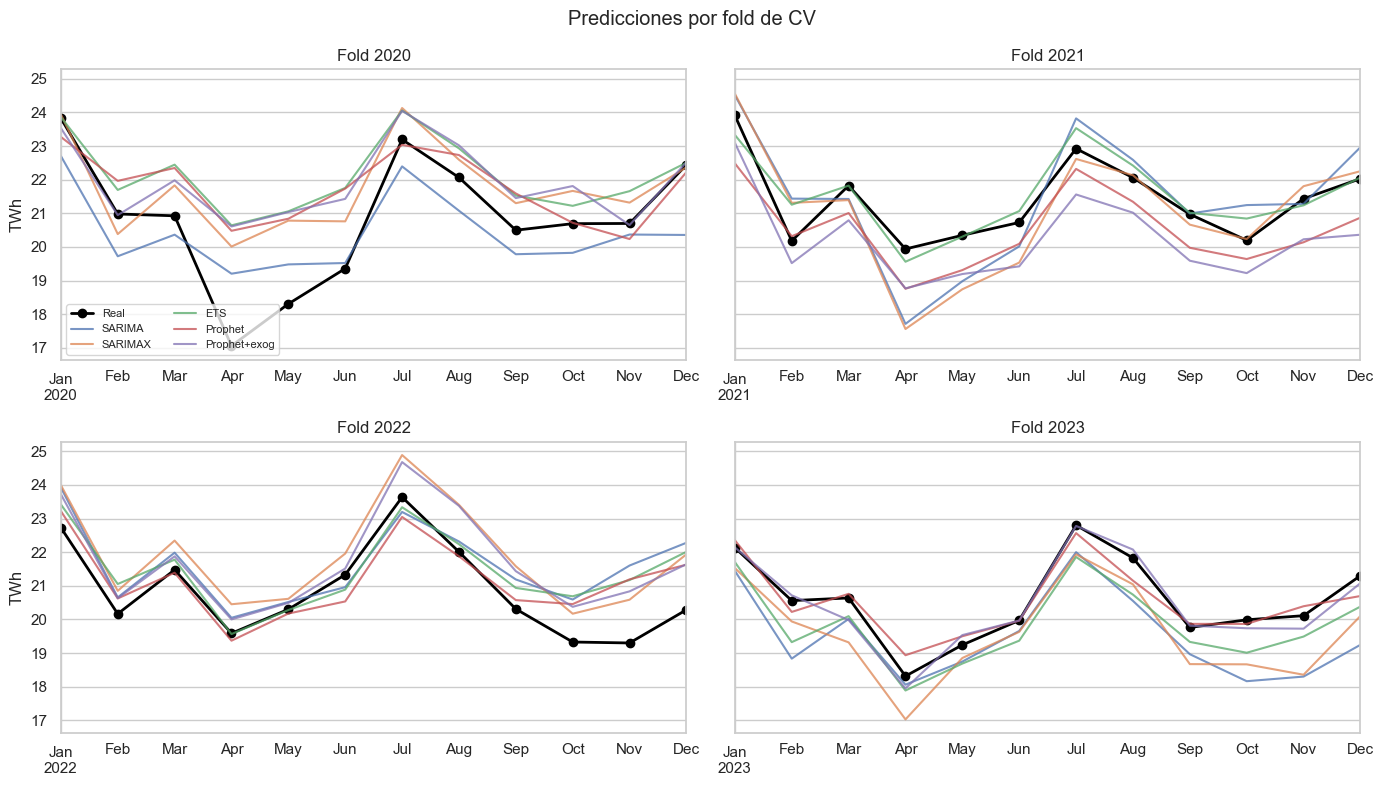

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=True)
for ax, (etiqueta, dfp) in zip(axes.flatten(), predicciones_cv.items()):
    (dfp['real'] / 1e6).plot(ax=ax, color='black', linewidth=2, label='Real', marker='o')
    for modelo in MODELOS:
        (dfp[modelo] / 1e6).plot(ax=ax, alpha=0.75, label=modelo)
    ax.set_title(f'Fold {etiqueta}')
    ax.set_ylabel('TWh'); ax.set_xlabel('')
axes[0, 0].legend(loc='lower left', fontsize=8, ncol=2)
plt.suptitle('Predicciones por fold de CV')
plt.tight_layout()

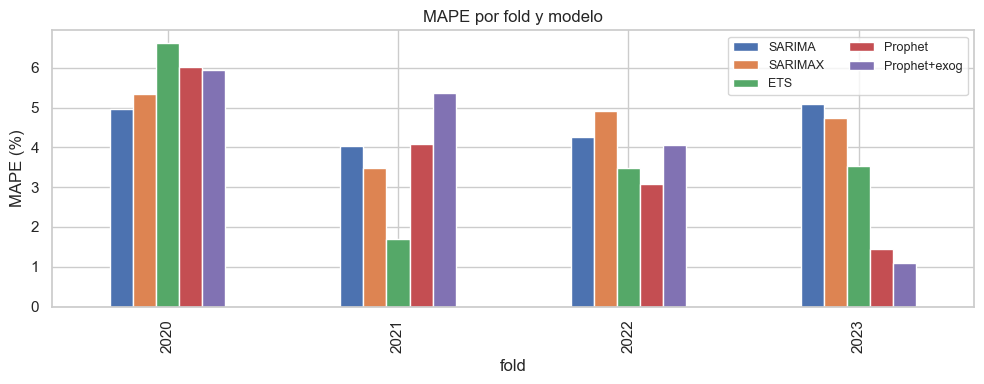

In [8]:
# Comparativa de MAPE por modelo y fold
fig, ax = plt.subplots(figsize=(10, 4))
pivot = resultados_cv.pivot(index='fold', columns='modelo', values='MAPE_%')
pivot[MODELOS].plot(kind='bar', ax=ax)
ax.set_ylabel('MAPE (%)')
ax.set_title('MAPE por fold y modelo')
ax.legend(loc='upper right', fontsize=9, ncol=2)
plt.tight_layout()

## 5. Evaluación final en hold-out (2024-2025)

Reentrenamos cada modelo con **todo** el train pre-holdout (2015-2023) y predecimos los 24 meses del hold-out.

In [9]:
filas_ho, predicciones_ho = [], pd.DataFrame(index=HOLDOUT.index)
predicciones_ho['real'] = HOLDOUT[TARGET]

for modelo in MODELOS:
    pred = predecir_uno(modelo, TRAIN_PRE_HOLDOUT, HOLDOUT)
    predicciones_ho[modelo] = pred
    # Metricas globales (24 meses)
    m_global = metricas(HOLDOUT[TARGET], pred)
    m_global.update({'modelo': modelo, 'periodo': 'global 2024-2025'})
    filas_ho.append(m_global)
    # Metricas separadas por anio
    for anio in [2024, 2025]:
        mask = HOLDOUT.index.year == anio
        m_anio = metricas(HOLDOUT.loc[mask, TARGET], pred[mask])
        m_anio.update({'modelo': modelo, 'periodo': str(anio)})
        filas_ho.append(m_anio)

resultados_ho = pd.DataFrame(filas_ho)[['periodo', 'modelo', 'MAPE_%', 'RMSE_MWh',
                                        'anual_real_TWh', 'anual_pred_TWh', 'error_anual_%']]
resultados_ho.round(2)

19:08:33 - cmdstanpy - INFO - Chain [1] start processing


19:08:33 - cmdstanpy - INFO - Chain [1] done processing


19:08:33 - cmdstanpy - INFO - Chain [1] start processing


19:08:33 - cmdstanpy - INFO - Chain [1] done processing


,periodo,modelo,MAPE_%,RMSE_MWh,anual_real_TWh,anual_pred_TWh,error_anual_%
0,global 2024-2025,SARIMA,5.43,1234205.52,505.09,532.16,5.36
1,2024,SARIMA,4.33,957118.07,249.00,259.70,4.30
2,2025,SARIMA,6.52,1459606.63,256.09,272.46,6.39
3,global 2024-2025,SARIMAX,1.96,527279.04,505.09,511.47,1.26
4,2024,SARIMAX,1.11,311937.01,249.00,250.18,0.47
5,2025,SARIMAX,2.80,677304.71,256.09,261.29,2.03
6,global 2024-2025,ETS,2.33,648281.18,505.09,496.46,-1.71
7,2024,ETS,1.64,408622.51,249.00,248.23,-0.31
8,2025,ETS,3.02,820709.83,256.09,248.23,-3.07
9,global 2024-2025,Prophet,4.67,1193287.04,505.09,481.68,-4.63


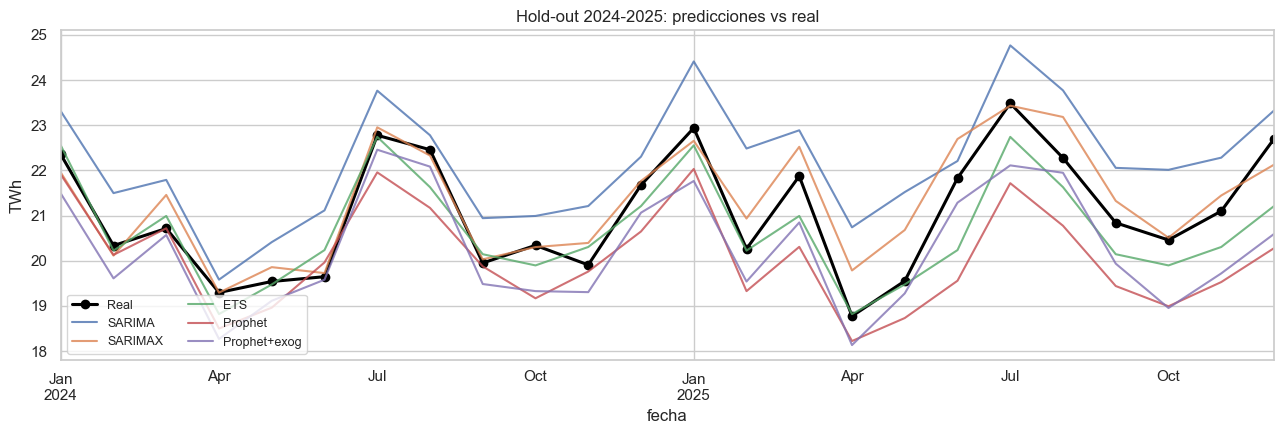

In [10]:
fig, ax = plt.subplots(figsize=(13, 4.5))
(predicciones_ho['real'] / 1e6).plot(ax=ax, color='black', linewidth=2.2, label='Real', marker='o')
for modelo in MODELOS:
    (predicciones_ho[modelo] / 1e6).plot(ax=ax, alpha=0.8, label=modelo)
ax.set_title('Hold-out 2024-2025: predicciones vs real')
ax.set_ylabel('TWh')
ax.legend(ncol=2, loc='lower left', fontsize=9)
plt.tight_layout()

## 6. Agregación a anual y entrega final

El TFM busca predicción **anual**. Sumamos las predicciones mensuales del hold-out y comparamos con el real.

In [11]:
anual_pred = (predicciones_ho.resample('YE').sum() / 1e6).round(2)
anual_pred.index = anual_pred.index.year
anual_err = anual_pred.subtract(anual_pred['real'], axis=0).div(anual_pred['real'], axis=0).mul(100).round(2)
anual_err = anual_err.drop(columns='real').rename(columns=lambda c: f'{c}_err_%')
tabla_anual = pd.concat([anual_pred, anual_err], axis=1)
print('Demanda anual (TWh) y error %:')
print(tabla_anual.to_string())

Demanda anual (TWh) y error %:
         real  SARIMA  SARIMAX     ETS  Prophet  Prophet+exog  SARIMA_err_%  SARIMAX_err_%  ETS_err_%  Prophet_err_%  Prophet+exog_err_%
fecha                                                                                                                                   
2024   249.00  259.70   250.18  248.23   242.77        242.36          4.30           0.47      -0.31          -2.50               -2.67
2025   256.09  272.46   261.29  248.23   238.91        244.11          6.39           2.03      -3.07          -6.71               -4.68


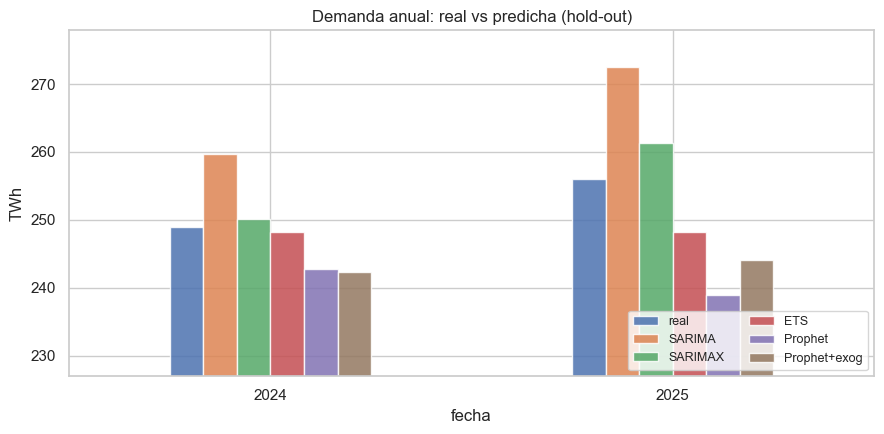

In [12]:
fig, ax = plt.subplots(figsize=(9, 4.5))
anual_pred.plot(kind='bar', ax=ax, alpha=0.85)
ax.set_ylabel('TWh')
ax.set_title('Demanda anual: real vs predicha (hold-out)')
ax.legend(loc='lower right', fontsize=9, ncol=2)
ax.set_ylim(anual_pred.values.min() * 0.95, anual_pred.values.max() * 1.02)
plt.xticks(rotation=0)
plt.tight_layout()

## 7. Conclusiones

*Pendiente de rellenar tras revisar los resultados ejecutados:*

- Mejor modelo según MAPE en CV (excluyendo COVID): **(ver tabla resumen)**
- Mejor modelo en hold-out 2024-2025: **(ver tabla)**
- ¿Aporta la temperatura (HDD/CDD) sobre la versión univariante?
  - SARIMA → SARIMAX: comparar MAPE
  - Prophet → Prophet+exog: comparar MAPE
- Comportamiento ante el shock COVID 2020: ¿qué modelo se recupera mejor?
- Limitaciones del estudio:
  - Hold-out usa temperatura observada (evaluación ex-post). Predicción operacional requiere pronóstico de temperatura.
  - 11 años de histórico mensual es modesto; SARIMA/ETS pueden infraajustar tendencias largas.
  - No se modelan calendarios laborales mensuales (días hábiles), que podrían reducir error.